In [27]:
# ==== Imports & Global Setup ====

import os
import torch
import pygame
import numpy as np
import torch.nn as nn
import gymnasium as gym
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.cuda.empty_cache()

# Seed everything
seed = 1111
np.random.seed(seed)
np.random.default_rng(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [28]:
# ==== Replay Memory ====
class ReplayMemory:
    def __init__(self, capacity):
        self.capacity = capacity
        
        self.states       = deque(maxlen=capacity)
        self.actions      = deque(maxlen=capacity)
        self.next_states  = deque(maxlen=capacity)
        self.rewards      = deque(maxlen=capacity)
        self.dones        = deque(maxlen=capacity)
        
    def store(self, state, action, next_state, reward, done):
        self.states.append(state)
        self.actions.append(action)
        self.next_states.append(next_state)
        self.rewards.append(reward)
        self.dones.append(done)
        
    def sample(self, batch_size):
        indices = np.random.choice(len(self), size=batch_size, replace=False)
        states = torch.stack([torch.as_tensor(self.states[i], dtype=torch.float32, device=device) for i in indices])
        actions = torch.as_tensor([self.actions[i] for i in indices], dtype=torch.long, device=device)
        next_states = torch.stack([torch.as_tensor(self.next_states[i], dtype=torch.float32, device=device) for i in indices])
        rewards = torch.as_tensor([self.rewards[i] for i in indices], dtype=torch.float32, device=device)
        dones = torch.as_tensor([1.0 if self.dones[i] else 0.0 for i in indices], dtype=torch.float32, device=device)

        return states, actions, next_states, rewards, dones
    
    def __len__(self):
        return len(self.dones)


In [29]:
# ==== Neural Network ====
class Network(nn.Module):
    def __init__(self, num_actions, input_dim):
        super(Network, self).__init__()
        
        self.FC = nn.Sequential(
            nn.Linear(input_dim, 24),
            nn.ReLU(inplace=True),
            nn.Linear(24, 16),
            nn.ReLU(inplace=True),
            nn.Linear(16, num_actions)
        )
        
        for layer in [self.FC]:
            for module in layer:
                if isinstance(module, nn.Linear):
                    nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')

    def forward(self, x):
        return self.FC(x)


In [30]:
# ==== DQN Agent ====
class Agent:
    def __init__(
        self,
        env,
        epsilon_max,
        epsilon_min,
        epsilon_decay,
        clip_grad_norm,
        learning_rate,
        discount,
        memory_capacity,
        tau=0.005,
    ):

        self.loss_history = []
        self.running_loss = 0.0
        self.learned_counts = 0

        self.epsilon_max = epsilon_max
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.epsilon = epsilon_max
        self.discount = discount

        self.action_space = env.action_space
        self.action_space.seed(seed)
        self.observation_space = env.observation_space
        self.replay_memory = ReplayMemory(memory_capacity)

        input_dim = self.observation_space.shape[0]
        output_dim = self.action_space.n

        self.main_network = Network(output_dim, input_dim).to(device)
        self.target_network = Network(output_dim, input_dim).to(device).eval()
        self.target_network.load_state_dict(self.main_network.state_dict())

        self.clip_grad_norm = clip_grad_norm
        self.criterion = nn.SmoothL1Loss()
        self.optimizer = optim.Adam(self.main_network.parameters(), lr=learning_rate)

        self.tau = tau
        self.learn_step_counter = 0

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return self.action_space.sample()

        if not torch.is_tensor(state):
            state = torch.as_tensor(state, dtype=torch.float32, device=device)

        with torch.no_grad():
            Q_values = self.main_network(state)
            return int(torch.argmax(Q_values).item())

    def soft_update(self):
        # theta_target = tau*theta_main + (1-tau)*theta_target
        for target_param, main_param in zip(
            self.target_network.parameters(), self.main_network.parameters()
        ):
            target_param.data.copy_(
                self.tau * main_param.data + (1.0 - self.tau) * target_param.data
            )

    def learn(self, batch_size, episode_done=False):
        states, actions, next_states, rewards, dones = self.replay_memory.sample(batch_size)

        actions = actions.unsqueeze(1)                         # (B,1)
        rewards = rewards.unsqueeze(1)                         # (B,1)
        dones = dones.unsqueeze(1).float()                     # (B,1) float mask 0/1

        # predicted Q for actions taken
        predicted_q = self.main_network(states).gather(1, actions)   # (B,1)

        # Double DQN:
        with torch.no_grad():
            # next action chosen by main network
            next_actions = self.main_network(next_states).argmax(dim=1, keepdim=True)  # (B,1)
            # evaluated by target network
            next_target_q_value = self.target_network(next_states).gather(1, next_actions)  # (B,1)

            # zero out target where transitions are terminal (done=True)
            target_q = rewards + (1.0 - dones) * (self.discount * next_target_q_value)

        loss = self.criterion(predicted_q, target_q)

        # statistics for plotting
        self.running_loss += loss.item()
        self.learned_counts += 1
        if episode_done:
            episode_loss = self.running_loss / max(1, self.learned_counts)
            self.loss_history.append(episode_loss)
            self.running_loss = 0.0
            self.learned_counts = 0

        # backprop
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.main_network.parameters(), self.clip_grad_norm)
        self.optimizer.step()

        # soft update every learn step
        self.soft_update()
        self.learn_step_counter += 1

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path):
        torch.save(self.main_network.state_dict(), path)

In [31]:
# ==== Environment Wrappers ====
class observation_wrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.min_value = env.observation_space.low
        self.max_value = env.observation_space.high

    def observation(self, state):
        return (state - self.min_value) / (self.max_value - self.min_value)

class reward_wrapper(gym.RewardWrapper):
    def reward(self, raw_state):
        current_position, current_velocity = raw_state

        modified_reward = 0.2 * (
            np.cos(np.deg2rad(current_position * 360)) + 2 * np.abs(current_velocity)
        )
        modified_reward -= 0.5

        if current_position > 0.48:  # almost at goal
            modified_reward += 10.0
        elif current_position > 0.40:  # close
            modified_reward += 4.0
        elif current_position > 0.30:  # moving toward it
            modified_reward += 1.0

        return float(np.clip(modified_reward, -50.0, 50.0))


class step_wrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_wrapper = observation_wrapper(env)
        self.reward_wrapper = reward_wrapper(env)

    def step(self, action):
        raw_next_state, env_reward, done, trunc, info = self.env.step(action)
        mod_reward = self.reward_wrapper.reward(raw_next_state)
        mod_state = self.observation_wrapper.observation(raw_next_state)
        return mod_state, mod_reward, done, trunc, info

    def reset(self, seed=None):
        raw_state, info = self.env.reset(seed=seed)
        mod_state = self.observation_wrapper.observation(raw_state)
        return mod_state, info

In [ ]:
# ==== Model Training & Testing ====

class Model_TrainTest():
    def __init__(self, hyperparams):
        self.train_mode = hyperparams["train_mode"]
        self.RL_load_path = hyperparams["RL_load_path"]
        self.save_path = hyperparams["save_path"]
        self.save_interval = hyperparams["save_interval"]

        self.clip_grad_norm = hyperparams["clip_grad_norm"]
        self.learning_rate = hyperparams["learning_rate"]
        self.discount_factor = hyperparams["discount_factor"]
        self.batch_size = hyperparams["batch_size"]
        self.max_episodes = hyperparams["max_episodes"]
        self.max_steps = hyperparams["max_steps"]
        self.render = hyperparams["render"]

        self.epsilon_max = hyperparams["epsilon_max"]
        self.epsilon_min = hyperparams["epsilon_min"]
        self.epsilon_decay = hyperparams["epsilon_decay"]

        self.memory_capacity = hyperparams["memory_capacity"]
        self.render_fps = hyperparams["render_fps"]
        
        self.env = gym.make('MountainCar-v0', max_episode_steps=self.max_steps, render_mode="human" if self.render else None)
        self.env.metadata['render_fps'] = self.render_fps
        self.env = step_wrapper(self.env)
        
        self.agent = Agent(
            env=self.env,
            epsilon_max=self.epsilon_max,
            epsilon_min=self.epsilon_min,
            epsilon_decay=self.epsilon_decay,
            clip_grad_norm=self.clip_grad_norm,
            learning_rate=self.learning_rate,
            discount=self.discount_factor,
            memory_capacity=self.memory_capacity
        )

    # ==== Training Loop ====

    def train(self): 
        total_steps = 0
        self.reward_history = []
        
        for episode in range(1, self.max_episodes+1):
            state, _ = self.env.reset(seed=seed)
            done = False
            trunc = False
            step_size = 0
            episode_reward = 0
                                                
            while not done and not trunc:
                action = self.agent.select_action(state)
                next_state, reward, done, trunc, _ = self.env.step(action)
                
                done_or_trunc = done or trunc
                self.agent.replay_memory.store(state, action, next_state, reward, done_or_trunc)
                
                if len(self.agent.replay_memory) > self.batch_size:
                    self.agent.learn(self.batch_size, episode_done=done_or_trunc)
                
                state = next_state
                episode_reward += reward
                step_size += 1

            self.reward_history.append(episode_reward)
            total_steps += step_size
            self.agent.update_epsilon()
                            
            if episode % self.save_interval == 0:
                self.agent.save(self.save_path + '_' + f'{episode}' + '.pth')
                if episode != self.max_episodes:
                    self.plot_training(episode)
                print('\n~~~~~~Interval Save: Model saved.\n')

            print(f"Episode: {episode}, Total Steps: {total_steps}, Ep Step: {step_size}, "
                    f"Raw Reward: {episode_reward:.2f}, Epsilon: {self.agent.epsilon:.2f}")
        
        self.plot_training(episode)
        
        
    # ==== Testing Loop ====

    def test(self, max_episodes):  
        self.agent.main_network.load_state_dict(torch.load(self.RL_load_path))
        self.agent.main_network.eval()
        
        for episode in range(1, max_episodes+1):         
            state, _ = self.env.reset(seed=seed)
            done = False
            trunc = False
            step_size = 0
            episode_reward = 0
                                                            
            while not done and not trunc:
                action = self.agent.select_action(state)
                next_state, reward, done, trunc, _ = self.env.step(action)
                                
                state = next_state
                episode_reward += reward
                step_size += 1
                                                                                                                        
            print(f"Episode: {episode}, Steps: {step_size}, Reward: {episode_reward:.2f}")
            
        pygame.quit()
        
    # ==== Plot ====
    def plot_training(self, episode):
        sma = np.convolve(self.reward_history, np.ones(50)/50, mode='valid')
        
        reward_history = np.clip(self.reward_history, None, 100)
        sma = np.clip(sma, None, 100)
                
        plt.figure()
        plt.title("Obtained Rewards")
        plt.plot(reward_history, label='Raw Reward', color='#4BA754')
        plt.plot(sma, label='SMA 50', color='#F08100')
        plt.xlabel("Episode")
        plt.ylabel("Rewards")
        plt.legend()
        if episode == self.max_episodes:
            plt.savefig('./reward_plot.png', dpi=600, bbox_inches='tight')
        plt.show()
        
        plt.figure()
        plt.title("Network Loss")
        plt.plot(self.agent.loss_history, label='Loss', color='#8921BB')
        plt.xlabel("Episode")
        plt.ylabel("Loss")
        if episode == self.max_episodes:
            plt.savefig('./Loss_plot.png', dpi=600, bbox_inches='tight')
        plt.show()


Episode: 1, Total Steps: 200, Ep Step: 200, Raw Reward: -133.60, Epsilon: 1.00
Episode: 2, Total Steps: 400, Ep Step: 200, Raw Reward: -129.70, Epsilon: 0.99
Episode: 3, Total Steps: 600, Ep Step: 200, Raw Reward: -130.50, Epsilon: 0.99
Episode: 4, Total Steps: 800, Ep Step: 200, Raw Reward: -137.14, Epsilon: 0.99
Episode: 5, Total Steps: 1000, Ep Step: 200, Raw Reward: -135.92, Epsilon: 0.98
Episode: 6, Total Steps: 1200, Ep Step: 200, Raw Reward: -135.69, Epsilon: 0.98
Episode: 7, Total Steps: 1400, Ep Step: 200, Raw Reward: -132.72, Epsilon: 0.98
Episode: 8, Total Steps: 1600, Ep Step: 200, Raw Reward: -127.40, Epsilon: 0.98
Episode: 9, Total Steps: 1800, Ep Step: 200, Raw Reward: -132.85, Epsilon: 0.97
Episode: 10, Total Steps: 2000, Ep Step: 200, Raw Reward: -120.03, Epsilon: 0.97
Episode: 11, Total Steps: 2200, Ep Step: 200, Raw Reward: -134.52, Epsilon: 0.97
Episode: 12, Total Steps: 2400, Ep Step: 200, Raw Reward: -125.54, Epsilon: 0.96
Episode: 13, Total Steps: 2600, Ep Step: 

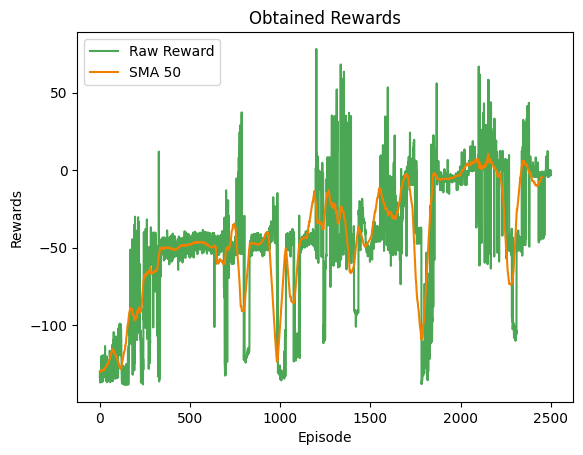

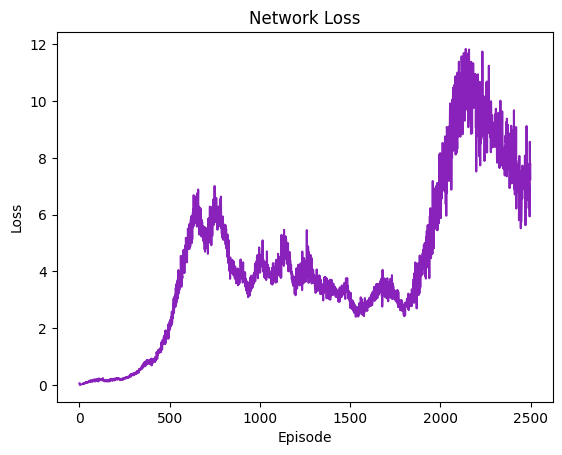


~~~~~~Interval Save: Model saved.

Episode: 2500, Total Steps: 360869, Ep Step: 87, Raw Reward: -3.26, Epsilon: 0.01
Episode: 2501, Total Steps: 360957, Ep Step: 88, Raw Reward: 0.01, Epsilon: 0.01
Episode: 2502, Total Steps: 361045, Ep Step: 88, Raw Reward: -0.07, Epsilon: 0.01
Episode: 2503, Total Steps: 361139, Ep Step: 94, Raw Reward: 2.20, Epsilon: 0.01
Episode: 2504, Total Steps: 361227, Ep Step: 88, Raw Reward: 0.01, Epsilon: 0.01
Episode: 2505, Total Steps: 361315, Ep Step: 88, Raw Reward: -0.13, Epsilon: 0.01
Episode: 2506, Total Steps: 361403, Ep Step: 88, Raw Reward: 0.01, Epsilon: 0.01
Episode: 2507, Total Steps: 361492, Ep Step: 89, Raw Reward: 3.41, Epsilon: 0.01
Episode: 2508, Total Steps: 361581, Ep Step: 89, Raw Reward: 6.21, Epsilon: 0.01
Episode: 2509, Total Steps: 361672, Ep Step: 91, Raw Reward: 2.95, Epsilon: 0.01
Episode: 2510, Total Steps: 361761, Ep Step: 89, Raw Reward: 6.21, Epsilon: 0.01
Episode: 2511, Total Steps: 361850, Ep Step: 89, Raw Reward: 6.21, Eps

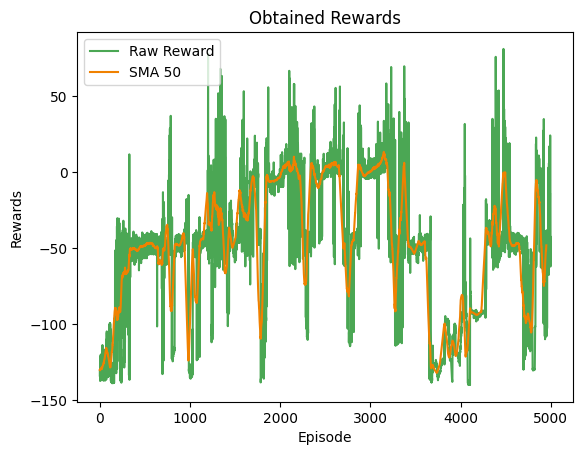

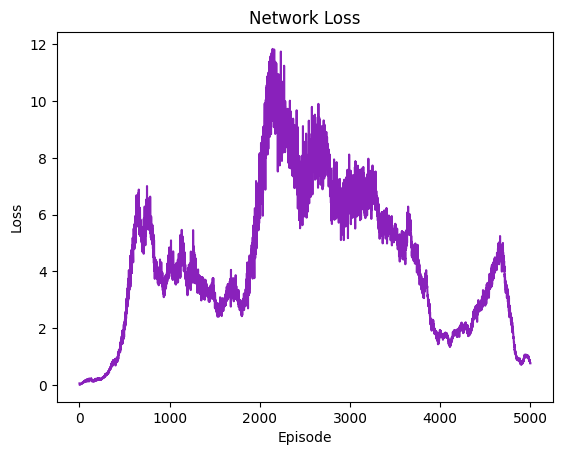

In [34]:
# ==== Main Runner ====

if __name__ == '__main__':
    train_mode = True
    render = False
    
    RL_hyperparams = {
        "train_mode": train_mode,
        "RL_load_path": './final_weights_1000.pth',
        "save_path": './final_weights',
        "save_interval": 2500,
        
        "clip_grad_norm": 5,
        "learning_rate": 3e-4,
        "discount_factor": 0.99,
        "batch_size": 64,
        "max_episodes": 5000 if train_mode else 20,
        "max_steps": 200,
        "render": render,
        
        "epsilon_max": 0.999 if train_mode else -1,
        "epsilon_min": 0.01,
        "epsilon_decay": 0.997,
        
        "memory_capacity": 50000 if train_mode else 0,
        "render_fps": 60,
    }
    
    DRL = Model_TrainTest(RL_hyperparams)
    
    if train_mode:
        DRL.train()
    else:
        DRL.test(max_episodes=RL_hyperparams['max_episodes'])
